# 1.4B Train Loss Curves

Plot baseline, Parallel Removal (Value), and Parallel Gating (Value) using raw CSV points only. The gate run uses `x_scale=0.1` to match the training-step accounting of the other runs.

In [1]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Match the EMNLP/ACL paper style, which uses the Times text font.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'analysis' / 'visualization' / 'loss_curves').is_dir() and (candidate / 'results' / 'figures').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate project root from {start}')


PAPER_ROOT = find_project_root()
DRAWING_DIR = PAPER_ROOT / 'analysis' / 'visualization' / 'loss_curves'
INPUT_DIR = DRAWING_DIR / 'data'
OUTPUT_DIR = PAPER_ROOT / 'results' / 'figures' / 'loss_curves'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUNS = [
    ("1p4_baseline.csv", "Baseline", 1.0),
    ("1p4_xsa.csv", "Parallel Removal (Value)", 1.0),
    ("1p4_gate.csv","Parallel Gating (Value)", 0.1),
]

PLOT_MIN_ITER = 450.0
PLOT_MAX_ITER = 6000.0
FIG_DPI = 220
FIGSIZE = (6.2, 3.4)
LINEWIDTH = 2.15
LABEL_FONTSIZE = 13
TICK_FONTSIZE = 11
LEGEND_FONTSIZE = 9
LINESTYLES = {
    "Baseline": "-",
    "Parallel Removal (Value)": ":",
    "Parallel Gating (Value)": "--",
}
CURVE_COLORS = {
    "Baseline": "#4c4c4c",
    "Parallel Removal (Value)": "#1f77b4",
    "Parallel Gating (Value)": "#d62728",
}

In [2]:
def clean(text: str) -> str:
    return (text or "").replace("\ufeff", "").strip()


def load_single_run(path: Path) -> tuple[list[float], list[float]]:
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        rows = list(csv.reader(f))
    xs, ys = [], []
    for row in rows[1:]:
        if len(row) < 2:
            continue
        try:
            xs.append(float(clean(row[0])))
            ys.append(float(clean(row[1])))
        except ValueError:
            continue
    if not xs:
        raise ValueError(f"No numeric rows found in {path}")
    return xs, ys


raw_series = []
for filename, label, x_scale in RUNS:
    xs, ys = load_single_run(INPUT_DIR / filename)
    xs = [x * x_scale for x in xs]
    raw_series.append((label, xs, ys))

start = max(PLOT_MIN_ITER, max(xs[0] for _, xs, _ in raw_series))
end = min(PLOT_MAX_ITER, min(xs[-1] for _, xs, _ in raw_series))
xlim = (start, end)
series = []
for label, xs, ys in raw_series:
    kept = [(x, y) for x, y in zip(xs, ys) if start <= x <= end]
    series.append((label, [x for x, _ in kept], [y for _, y in kept]))

summary_rows = []
for label, xs, ys in series:
    summary_rows.append({
        "setting": label,
        "n_points": len(xs),
        "first_iter": xs[0],
        "last_iter": xs[-1],
        "first_loss": ys[0],
        "last_loss": ys[-1],
        "min_loss": min(ys),
    })
summary_rows

[{'setting': 'Baseline',
  'n_points': 44,
  'first_iter': 505.0,
  'last_iter': 4848.0,
  'first_loss': 3.09946,
  'last_loss': 2.731724,
  'min_loss': 2.714624},
 {'setting': 'Parallel Removal (Value)',
  'n_points': 44,
  'first_iter': 505.0,
  'last_iter': 4848.0,
  'first_loss': 3.053495,
  'last_loss': 2.710706,
  'min_loss': 2.693111},
 {'setting': 'Parallel Gating (Value)',
  'n_points': 45,
  'first_iter': 500.0,
  'last_iter': 4900.0,
  'first_loss': 3.067737,
  'last_loss': 2.696394,
  'min_loss': 2.689454}]

PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/figs/loss_curves/loss_1p4_gate_vs_xsa_absolute.png')

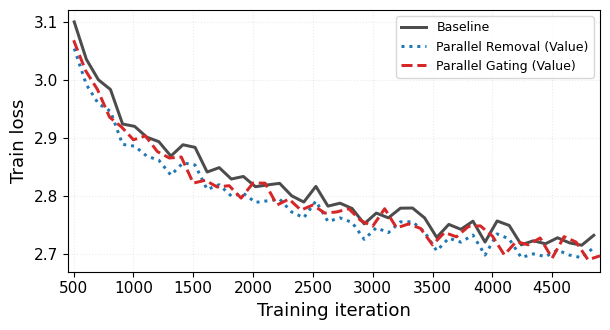

In [3]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for label, xs, ys in series:
    ax.plot(
        xs, ys,
        linewidth=LINEWIDTH,
        linestyle=LINESTYLES.get(label, "-"),
        color=CURVE_COLORS.get(label),
        label=label,
    )
ax.set_xlim(*xlim)
ax.set_xlabel("Training iteration", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Train loss", fontsize=LABEL_FONTSIZE)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, fontsize=LEGEND_FONTSIZE, facecolor="white", edgecolor="#cfcfcf", loc="upper right")
fig.tight_layout()

absolute_path = OUTPUT_DIR / "loss_1p4_gate_vs_xsa_absolute.png"
fig.savefig(absolute_path, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(absolute_path.with_suffix(".pdf"), bbox_inches="tight")
absolute_path


PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/figs/loss_curves/loss_1p4_gate_vs_xsa_delta.png')

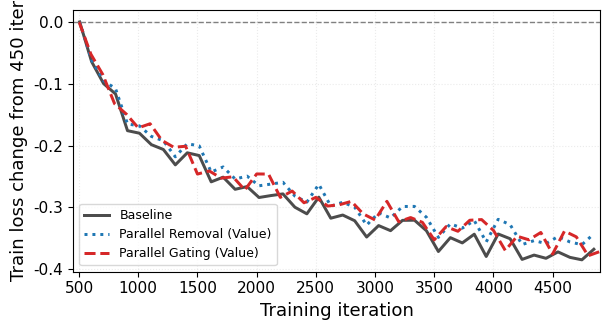

In [4]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for label, xs, ys in series:
    base = ys[0]
    ax.plot(
        xs, [y - base for y in ys],
        linewidth=LINEWIDTH,
        linestyle=LINESTYLES.get(label, "-"),
        color=CURVE_COLORS.get(label),
        label=label,
    )
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
ax.set_xlim(*xlim)
ax.set_xlabel("Training iteration", fontsize=LABEL_FONTSIZE)
ax.set_ylabel(f"Train loss change from {int(PLOT_MIN_ITER)} iter", fontsize=LABEL_FONTSIZE)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.grid(alpha=0.25, linestyle=":")
ax.legend(frameon=True, fontsize=LEGEND_FONTSIZE, facecolor="white", edgecolor="#cfcfcf", loc="lower left")
fig.tight_layout()
delta_path = OUTPUT_DIR / "loss_1p4_gate_vs_xsa_delta.png"
fig.savefig(delta_path, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(delta_path.with_suffix(".pdf"), bbox_inches="tight")
delta_path

In [5]:
summary_path = OUTPUT_DIR / "loss_1p4_gate_vs_xsa_summary.csv"
with summary_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)
summary_path

PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/figs/loss_curves/loss_1p4_gate_vs_xsa_summary.csv')